# GLOBAL VARIABLE

In [1]:
BATCH_SIZE = 4

# Create Custom Dataset for PyTorch

In [2]:
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

class CustomDataset_general(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_folder = os.path.join(root_dir, "images")
        self.mask_folder = os.path.join(root_dir, "masks")
        self.image_files = sorted(os.listdir(self.image_folder))
        self.mask_files = sorted(os.listdir(self.mask_folder))
        self.transform = transform

    def __len__(self):
        return len(self.mask_files)

    def __getitem__(self, idx):
        # Read image
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_folder, img_name)
        image = Image.open(img_path).convert("RGB")
        image_gray = image.convert("L")  # Convert to grayscale

        # Read corresponding mask
        mask_name = self.mask_files[idx]
        mask_path = os.path.join(self.mask_folder, mask_name)
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            # Apply transformations
            image_gray = self.transform(image_gray)
            mask = self.transform(mask)

        return image_gray, mask

# Define paths for train, validation, and test sets
train_path = "/mnt/c/Users/kanek/University/Coding-Webe-Kuliah/Tugas/Semester-4/Deep_Learning/Project/Image_segmentation/train2" 
valid_path = "/mnt/c/Users/kanek/University/Coding-Webe-Kuliah/Tugas/Semester-4/Deep_Learning/Project/Image_segmentation/valid2"
test_path = "/mnt/c/Users/kanek/University/Coding-Webe-Kuliah/Tugas/Semester-4/Deep_Learning/Project/Image_segmentation/test2"

# Define transformations
image_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),  # Assuming grayscale images
    transforms.Lambda(lambda x: x.clamp(0, 1))
])

# Create datasets
train_dataset = CustomDataset_general(train_path, transform=image_transform)
valid_dataset = CustomDataset_general(valid_path, transform=image_transform)
test_dataset = CustomDataset_general(test_path, transform=image_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [3]:
print(len(train_loader))

376


In [4]:
if len(train_loader) > 0:
    x, y = next(iter(train_loader))
    print(x.shape , y.shape , type(x) , type(y))
else:
    print("Train loader is empty.")


torch.Size([4, 1, 224, 224]) torch.Size([4, 1, 224, 224]) <class 'torch.Tensor'> <class 'torch.Tensor'>


# Modelling

## Import Libraries

In [5]:
import torch
from torchvision import datasets
from torchmetrics.classification import BinaryJaccardIndex
from torch.utils.data import Dataset ,DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.optim import lr_scheduler

## Loss

In [6]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
        
    def forward(self, y_pred, y_true):
        y_pred = torch.sigmoid(y_pred)
        smooth = 1.0
        y_pred = y_pred.reshape(-1)
        y_true = y_true.reshape(-1)
        intersection = (y_pred * y_true).sum()
        
        dic_loss = 1 - (2.0 * intersection + smooth) / (y_pred.sum() + y_true.sum() + smooth)
        return dic_loss

## Import Backbone

In [7]:
import segmentation_models_pytorch as smp


ENCODER = 'efficientnet-b0'
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda'

ACTIVATION = None
model = smp.Unet(
    encoder_name=ENCODER, 
    encoder_weights=ENCODER_WEIGHTS, 
    in_channels=1, 
    classes=1, 
    activation=ACTIVATION,
)

/home/wbchn/miniconda3/envs/PyTorch-DLN/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hyperparameters

In [8]:
checkpoints_path = "exp/checkpoints.pth"
os.makedirs("exp", exist_ok=True)

num_epochs = 1
lr=1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = DiceLoss()

## Defining Model

In [18]:
from tqdm import tqdm
def train(model,optimizer,loss_fn,loader,device):
    epoch_loss =0.0
    model.train()
    
    for x,y in tqdm(loader):
        x = x.to(device, dtype = torch.float32)
        y = y.to(device, dtype = torch.float32)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        optimizer.step()
        epoch_loss +=loss.item()
    
    return epoch_loss/len(loader)
        

In [19]:
def valid(model,loader,loss_fn,device):
    epoch_loss = 0.0
    model.eval()
    
    for x,y in loader:
        x = x.to(device, dtype = torch.float32)
        y = y.to(device, dtype = torch.float32)
        pred = model(x)
        loss = loss_fn(pred,y)
        epoch_loss +=loss.item()
    return epoch_loss/len(loader)

## Model Training

Epoch 1/1, Train Loss: 0.5882, Train Acc: 0.4118
Cross Loss: 0.4955, Cross Acc: 0.0000
Saving the model


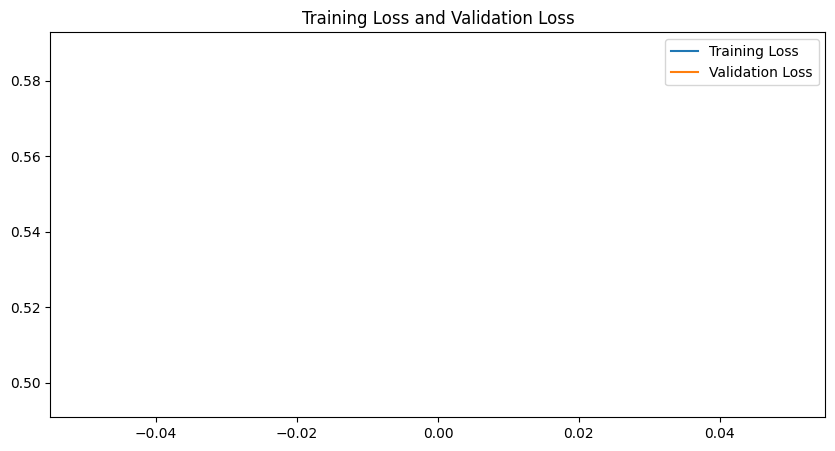

In [20]:
from IPython.display import clear_output
from matplotlib import pyplot as plt

best_val_loss = float('inf')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses = []

model.to(device)  # Move the model to the appropriate device

for epoch in range(num_epochs):
    train_loss = train(model,optimizer,loss_fn,train_loader,device)
    val_loss = valid(model,valid_loader,loss_fn,device)
    train_losses.append(train_loss)
    
    clear_output(wait=True)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Dice Loss: {train_loss:.4f}, Train Dice Similarity Coef: {1-train_loss:.4f}')
    print(f'Validation Dice Loss: {val_loss:.4f}, Validation Dice Similarity Coef: {1-val_loss:.4f}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print("Saving the model")
        torch.save(model.state_dict(), checkpoints_path)
        
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training Loss and Validation Loss')
plt.legend()
plt.show(block=False)